In [1]:
import requests

In [ ]:
URL = "https://date.nager.at/api/v3/publicholidays/2026/AT" 
res = requests.get(URL)   

In [ ]:
print(res.status_code)

200


In [ ]:
data = res.json()

In [ ]:
import pandas as pd

In [ ]:
df = pd.json_normalize(data[:])

In [ ]:
df

,date,localName,name,countryCode,fixed,global,counties,launchYear,types
0,2026-01-01,Neujahr,New Year's Day,AT,False,True,None,None,[Public]
1,2026-01-06,Heilige Drei Könige,Epiphany,AT,False,True,None,None,[Public]
2,2026-04-05,Ostersonntag,Easter Sunday,AT,False,True,None,None,[Public]
3,2026-04-06,Ostermontag,Easter Monday,AT,False,True,None,None,[Public]
4,2026-05-01,Staatsfeiertag,National Holiday,AT,False,True,None,None,[Public]
5,2026-05-14,Christi Himmelfahrt,Ascension Day,AT,False,True,None,None,[Public]
6,2026-05-24,Pfingstsonntag,Pentecost,AT,False,True,None,None,[Public]
7,2026-05-25,Pfingstmontag,Whit Monday,AT,False,True,None,None,[Public]
8,2026-06-04,Fronleichnam,Corpus Christi,AT,False,True,None,None,[Public]
9,2026-08-15,Maria Himmelfahrt,Assumption Day,AT,False,True,None,None,[Public]


In [ ]:
df.isna().sum()

date            0
localName       0
name            0
countryCode     0
fixed           0
global          0
counties       15
launchYear     15
types           0
dtype: int64

In [ ]:
print(type(df))

<class 'pandas.DataFrame'>


In [33]:
df.describe()

,date,localName,name,countryCode,fixed,global,counties,launchYear,types
count,15,15,15,15,15,15,0,0,15
unique,15,15,14,1,1,1,0,0,1
top,2026-01-01,Neujahr,National Holiday,AT,False,True,NaN,NaN,[Public]
freq,1,1,2,15,15,15,NaN,NaN,15


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         15 non-null     str   
 1   localName    15 non-null     str   
 2   name         15 non-null     str   
 3   countryCode  15 non-null     str   
 4   fixed        15 non-null     bool  
 5   global       15 non-null     bool  
 6   counties     0 non-null      object
 7   launchYear   0 non-null      object
 8   types        15 non-null     object
dtypes: bool(2), object(3), str(4)
memory usage: 1002.0+ bytes


In [44]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         15 non-null     datetime64[us]
 1   localName    15 non-null     str           
 2   name         15 non-null     str           
 3   countryCode  15 non-null     str           
 4   fixed        15 non-null     bool          
 5   global       15 non-null     bool          
 6   counties     0 non-null      object        
 7   launchYear   0 non-null      object        
 8   types        15 non-null     object        
 9   month        15 non-null     int32         
dtypes: bool(2), datetime64[us](1), int32(1), object(3), str(3)
memory usage: 1.0+ KB


In [43]:
import matplotlib.pyplot as plt

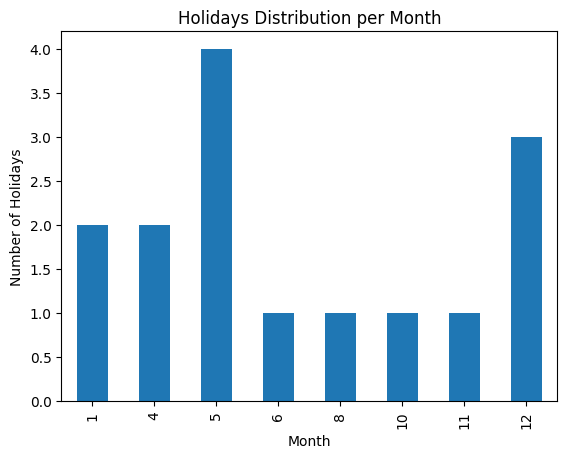

In [46]:
df['month'].value_counts().sort_index().plot(kind='bar') 

plt.xlabel("Month")
plt.ylabel("Number of Holidays") 
plt.title("Holidays Distribution per Month") 
plt.show()

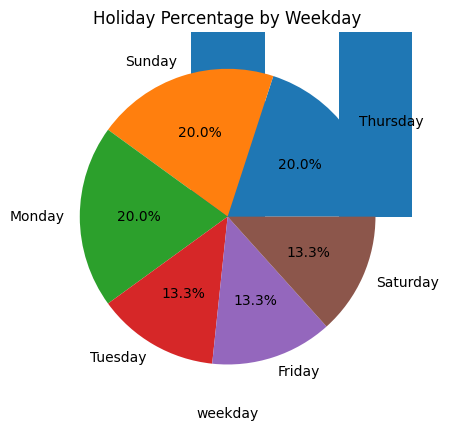

In [ ]:
df['weekday'] = df['date'].dt.day_name()
df['weekday'].value_counts().plot(kind='bar')
df['weekday'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")
plt.title("Holiday Percentage by Weekday")
plt.show()

In [55]:
df[df["weekday"] == 'Thursday']

,date,localName,name,countryCode,fixed,global,counties,launchYear,types,month,weekday
0,2026-01-01,Neujahr,New Year's Day,AT,False,True,None,None,[Public],1,Thursday
5,2026-05-14,Christi Himmelfahrt,Ascension Day,AT,False,True,None,None,[Public],5,Thursday
8,2026-06-04,Fronleichnam,Corpus Christi,AT,False,True,None,None,[Public],6,Thursday
